# **Driver Lifetime Value**

_This data project has been used as a take-home assignment in the recruitment process for the data science positions at Lyft._

Assignment
----------

After exploring and analyzing the data, please:

1.  Recommend a Driver's Lifetime Value (i.e., the value of a driver to Lyft over the entire projected lifetime of a driver).
2.  Please answer the following questions:
    *   What are the main factors that affect a driver's lifetime value?
    *   What is the average projected lifetime of a driver? That is, once a driver is onboarded, how long do they typically continue driving with Lyft?
    *   Do all drivers act alike? Are there specific segments of drivers that generate more value for Lyft than the average driver?
    *   What actionable recommendations are there for the business?
3.  Prepare and submit a writeup of your findings for consumption by a cross-functional audience.

You can make the following assumptions about the Lyft rate card:

*   Base Fare $2.00
*   Cost per Mile $1.15
*   Cost per Minute $0.22
*   Service Fee $1.75
*   Minimum Fare $5.00
*   Maximum Fare $400.00

Data Description
----------------

You'll find three CSV files attached with the following data:

**driver\_ids.csv**

*   `driver_id` Unique identifier for a driver
*   `driver_onboard_date` Date on which driver was on-boarded

**ride\_ids.csv**

*   `driver_id` Unique identifier for a driver
*   `ride_id` Unique identifier for a ride that was completed by the driver
*   `ride_distance` Ride distance in meters
*   `ride_duration` Ride duration in seconds
*   `ride_prime_time` Prime Time applied on the ride

**ride\_timestamps.csv**

*   `ride_id` Unique identifier for a ride
*   `event` describes the type of event; this variable takes the following values:
    *   _requested\_at_ - passenger requested a ride
    *   _accepted\_at_ - driver accepted a passenger request
    *   _arrived\_at_ - driver arrived at pickup point
    *   _picked\_up\_at_ - driver picked up the passenger
    *   _dropped\_off\_at_ - driver dropped off a passenger at destination
*   `timestamp` Time of event

You can assume that:

*   All rides in the data set occurred in San Francisco
*   All timestamps in the data set are in UTC

Practicalities
--------------

Please work on the questions in the displayed order. Make sure that the solution reflects your entire thought process - it is more important how the code is structured rather than the final answers. You are expected to spend no more than 2 hours solving this project.

## Data Preparation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import plotly.graph_objects as go
import plotly.express as px

fig = go.Figure()
sns.set_style("whitegrid")

driver_data = pd.read_csv('datasets/driver_ids.csv')
ride_data = pd.read_csv('datasets/ride_ids.csv')
ride_timestamps_data = pd.read_csv('datasets/ride_timestamps.csv')

driver_data['driver_onboard_date'] = pd.to_datetime(driver_data['driver_onboard_date'])
ride_timestamps_data['timestamp'] = pd.to_datetime(ride_timestamps_data['timestamp'])

# Merge the data base on the id

df = driver_data.merge(ride_data, on='driver_id').merge(ride_timestamps_data, on='ride_id')
df.head(10)

,driver_id,driver_onboard_date,ride_id,ride_distance,ride_duration,ride_prime_time,event,timestamp
0,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,requested_at,2016-04-23 02:13:50
1,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,accepted_at,2016-04-23 02:14:15
2,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,arrived_at,2016-04-23 02:16:36
3,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,picked_up_at,2016-04-23 02:16:40
4,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,dropped_off_at,2016-04-23 02:22:07
5,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,requested_at,2016-03-29 19:00:49
6,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,accepted_at,2016-03-29 19:00:52
7,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,arrived_at,2016-03-29 19:03:57
8,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,picked_up_at,2016-03-29 19:04:01
9,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,dropped_off_at,2016-03-29 19:17:30


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 921045 entries, 0 to 921044
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   driver_id            921045 non-null  object        
 1   driver_onboard_date  921045 non-null  datetime64[ns]
 2   ride_id              921045 non-null  object        
 3   ride_distance        921045 non-null  int64         
 4   ride_duration        921045 non-null  int64         
 5   ride_prime_time      921045 non-null  int64         
 6   event                921045 non-null  object        
 7   timestamp            921044 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(3), object(3)
memory usage: 56.2+ MB


In [3]:
df.shape

(921045, 8)

### Check for Missing Data

In [4]:
def missing_data(input_data):
    total = input_data.isnull().sum()
    percent = (input_data.isnull().sum() / input_data.isnull().count() * 100)
    table = pd.concat([total, percent], axis = 1, keys = ['Total', 'Percent'])
    types = []
    for col in input_data.columns:
        dtype = str(input_data[col].dtype)
        types.append(dtype)
    table["Types"] = types
    return(pd.DataFrame(table)) 

missing_data(df)


,Total,Percent,Types
driver_id,0,0.000000,object
driver_onboard_date,0,0.000000,datetime64[ns]
ride_id,0,0.000000,object
ride_distance,0,0.000000,int64
ride_duration,0,0.000000,int64
ride_prime_time,0,0.000000,int64
event,0,0.000000,object
timestamp,1,0.000109,datetime64[ns]


In [5]:
df['timestamp'] = df['timestamp'].ffill()

In [6]:
missing_data(df)

,Total,Percent,Types
driver_id,0,0.0,object
driver_onboard_date,0,0.0,datetime64[ns]
ride_id,0,0.0,object
ride_distance,0,0.0,int64
ride_duration,0,0.0,int64
ride_prime_time,0,0.0,int64
event,0,0.0,object
timestamp,0,0.0,datetime64[ns]


## Feature Engineering

### Driver's Lifetime

In [7]:
latest_timestamp = df['timestamp'].max()
df['driver_lifetime_days'] = (latest_timestamp - df['driver_onboard_date']).dt.days

### Ride Details

In [8]:
df['ride_duration_minutes'] = df['ride_duration'] / 60
df['ride_distance_miles'] = df['ride_distance'] / 1609.34
df['is_prime_time'] = df['ride_prime_time'] > 0

prime_time_proportion = df.groupby('driver_id')['is_prime_time'].mean().reset_index()
prime_time_proportion.columns = ['driver_id', 'prime_time_percentage']

df = df.merge(prime_time_proportion, on='driver_id', how='left')

df.head(10)

,driver_id,driver_onboard_date,ride_id,ride_distance,ride_duration,ride_prime_time,event,timestamp,driver_lifetime_days,ride_duration_minutes,ride_distance_miles,is_prime_time,prime_time_percentage
0,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,requested_at,2016-04-23 02:13:50,90,5.450000,1.125306,True,0.397112
1,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,accepted_at,2016-04-23 02:14:15,90,5.450000,1.125306,True,0.397112
2,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,arrived_at,2016-04-23 02:16:36,90,5.450000,1.125306,True,0.397112
3,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,picked_up_at,2016-04-23 02:16:40,90,5.450000,1.125306,True,0.397112
4,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,dropped_off_at,2016-04-23 02:22:07,90,5.450000,1.125306,True,0.397112
5,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,requested_at,2016-03-29 19:00:49,90,13.483333,2.089055,False,0.397112
6,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,accepted_at,2016-03-29 19:00:52,90,13.483333,2.089055,False,0.397112
7,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,arrived_at,2016-03-29 19:03:57,90,13.483333,2.089055,False,0.397112
8,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,picked_up_at,2016-03-29 19:04:01,90,13.483333,2.089055,False,0.397112
9,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,dropped_off_at,2016-03-29 19:17:30,90,13.483333,2.089055,False,0.397112


### Total Earnings

In [9]:
BASE_FARE = 2.00
COST_PER_MILE = 1.15
COST_PER_MINUTE = 0.22
SERVICE_FEE = 1.75
MIN_FARE = 5.00
MAX_FARE = 400.00


df['ride_fare'] = (BASE_FARE + (COST_PER_MILE * df['ride_distance_miles']) + (COST_PER_MINUTE * df['ride_duration_minutes']) + SERVICE_FEE)
df['ride_fare'] = df['ride_fare'].clip(lower=MIN_FARE, upper=MAX_FARE)

df.head(10)

,driver_id,driver_onboard_date,ride_id,ride_distance,ride_duration,ride_prime_time,event,timestamp,driver_lifetime_days,ride_duration_minutes,ride_distance_miles,is_prime_time,prime_time_percentage,ride_fare
0,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,requested_at,2016-04-23 02:13:50,90,5.450000,1.125306,True,0.397112,6.243102
1,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,accepted_at,2016-04-23 02:14:15,90,5.450000,1.125306,True,0.397112,6.243102
2,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,arrived_at,2016-04-23 02:16:36,90,5.450000,1.125306,True,0.397112,6.243102
3,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,picked_up_at,2016-04-23 02:16:40,90,5.450000,1.125306,True,0.397112,6.243102
4,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,dropped_off_at,2016-04-23 02:22:07,90,5.450000,1.125306,True,0.397112,6.243102
5,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,requested_at,2016-03-29 19:00:49,90,13.483333,2.089055,False,0.397112,9.118747
6,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,accepted_at,2016-03-29 19:00:52,90,13.483333,2.089055,False,0.397112,9.118747
7,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,arrived_at,2016-03-29 19:03:57,90,13.483333,2.089055,False,0.397112,9.118747
8,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,picked_up_at,2016-03-29 19:04:01,90,13.483333,2.089055,False,0.397112,9.118747
9,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,dropped_off_at,2016-03-29 19:17:30,90,13.483333,2.089055,False,0.397112,9.118747


## Answering Questions

### Recommend a Driver’s Lifetime Value

In [10]:
driver_ltv = df.groupby('driver_id')['ride_fare'].sum().reset_index()
driver_ltv.columns = ['driver_id', 'ltv']

# Merge LTV back to the main dataframe
df = df.merge(driver_ltv, on='driver_id', how='left')
df.head(10)

,driver_id,driver_onboard_date,ride_id,ride_distance,ride_duration,ride_prime_time,event,timestamp,driver_lifetime_days,ride_duration_minutes,ride_distance_miles,is_prime_time,prime_time_percentage,ride_fare,ltv
0,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,requested_at,2016-04-23 02:13:50,90,5.450000,1.125306,True,0.397112,6.243102,15470.199584
1,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,accepted_at,2016-04-23 02:14:15,90,5.450000,1.125306,True,0.397112,6.243102,15470.199584
2,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,arrived_at,2016-04-23 02:16:36,90,5.450000,1.125306,True,0.397112,6.243102,15470.199584
3,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,picked_up_at,2016-04-23 02:16:40,90,5.450000,1.125306,True,0.397112,6.243102,15470.199584
4,002be0ffdc997bd5c50703158b7c2491,2016-03-29,006d61cf7446e682f7bc50b0f8a5bea5,1811,327,50,dropped_off_at,2016-04-23 02:22:07,90,5.450000,1.125306,True,0.397112,6.243102,15470.199584
5,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,requested_at,2016-03-29 19:00:49,90,13.483333,2.089055,False,0.397112,9.118747,15470.199584
6,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,accepted_at,2016-03-29 19:00:52,90,13.483333,2.089055,False,0.397112,9.118747,15470.199584
7,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,arrived_at,2016-03-29 19:03:57,90,13.483333,2.089055,False,0.397112,9.118747,15470.199584
8,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,picked_up_at,2016-03-29 19:04:01,90,13.483333,2.089055,False,0.397112,9.118747,15470.199584
9,002be0ffdc997bd5c50703158b7c2491,2016-03-29,01b522c5c3a756fbdb12e95e87507eda,3362,809,0,dropped_off_at,2016-03-29 19:17:30,90,13.483333,2.089055,False,0.397112,9.118747,15470.199584


### Factors Affecting LTV

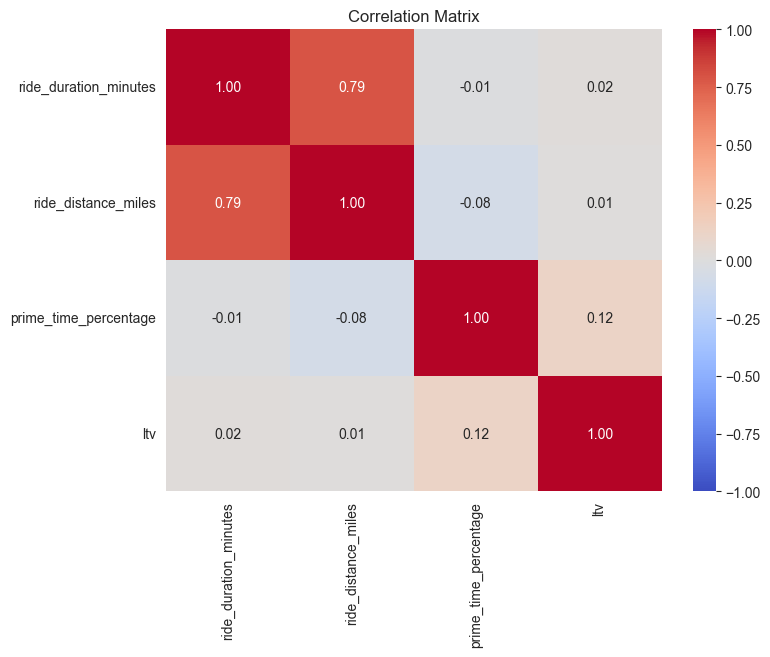

In [11]:
correlation = df[['ride_duration_minutes', 'ride_distance_miles', 'prime_time_percentage', 'ltv']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

### Average Projected Lifetime of a Driver

In [12]:
average_lifetime = df.groupby('driver_id')['driver_lifetime_days'].mean().mean()
print(f"Average projected lifetime of a driver: {average_lifetime:.2f} days")

Average projected lifetime of a driver: 68.99 days


## Driver Segmentation

In [13]:
features = df[['ride_duration_minutes', 'ride_distance_miles', 'prime_time_percentage']].fillna(0)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

sse = []
silhouette_scores = []
for k in range(2, 11):
    mini_kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000, n_init=10)
    mini_kmeans.fit(features_scaled)
    sse.append(mini_kmeans.inertia_)

    if k > 1:
        score = silhouette_score(features_scaled, mini_kmeans.labels_)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(None)

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(range(2, 11), sse, marker='o', color='tab:blue', label='SSE')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('SSE', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(range(2, 11), silhouette_scores, marker='o', color='tab:orange', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Elbow Method with Silhouette Score for Optimal K')
fig.tight_layout()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['driver_segment'] = kmeans.fit_predict(features_scaled)
segment_summary = df.groupby('driver_segment')[['ltv', 'ride_duration_minutes', 'ride_distance_miles', 'prime_time_percentage']].mean()
segment_summary

## Visualization

### LTV Distribution

In [ ]:
sns.histplot(driver_ltv['ltv'], bins=30, kde=True)
plt.title('LTV Distribution')
plt.xlabel('Lifetime Value (LTV)')
plt.ylabel('Frequency')
plt.show()

### Driver Segments

In [ ]:
sns.boxplot(x='driver_segment', y='ltv', data=df)
plt.title('LTV by Driver Segment')
plt.xlabel('Driver Segment')
plt.ylabel('Lifetime Value (LTV)')
plt.show()

### Factors Influencing LTV

In [ ]:
sns.scatterplot(x='ride_distance_miles', y='ltv', data=df)
plt.title('Impact of Ride Distance on LTV')
plt.xlabel('Ride Distance (miles)')
plt.ylabel('Lifetime Value (LTV)')
plt.show()